In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
import tensorflow as tf
from sklearn.datasets import make_classification
from magloss import mag_loss_tf as mag_loss
from magloss import spread_loss_tf as spread_loss

In [24]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=10,
    n_clusters_per_class=1,
    weights=[0.5] + [0.055]*9,
    flip_y=0.01,
    random_state=42
)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

In [109]:
def build_model(input_dim, loss_name, num_classes):
    model = Sequential()
    model.add(Dense(32, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=SGD(0.01), loss=loss_name, metrics=[tf.keras.metrics.AUC(curve = 'PR', name = 'auc'),
                                                                'accuracy', 
                                                                tf.keras.metrics.F1Score(average = 'micro', name = 'micro'),
                                                               tf.keras.metrics.F1Score(average = 'macro', name = 'macro')])
    return model

In [110]:
loss_functions = {
    "Magnitude": (mag_loss(), y_train_onehot, y_test_onehot),
    "Spread": (spread_loss(), y_train_onehot, y_test_onehot),
    "Categorical Crossentropy": ("categorical_crossentropy", y_train_onehot, y_test_onehot),
    "MSE (One-hot)": ("mean_squared_error", y_train_onehot, y_test_onehot),
}
results = {}
losses = {}
aucs = {}
micros = {}
macros = {}

for name, (loss_fn, y_tr, y_te) in loss_functions.items():
    print(f"\nTraining with {name}...")
    model = build_model(input_dim=20, loss_name=loss_fn, num_classes=10)
    history = model.fit(X_train, y_tr, validation_data=(X_test, y_te),
                        epochs=100, verbose=0)
    results[name] = history.history['val_accuracy']
    losses[name] = history.history['val_loss']
    aucs[name] = history.history['val_auc']
    micros[name] = history.history['val_micro']
    macros[name] = history.history['val_macro']
    


Training with Magnitude...

Training with Spread...

Training with Categorical Crossentropy...

Training with MSE (One-hot)...


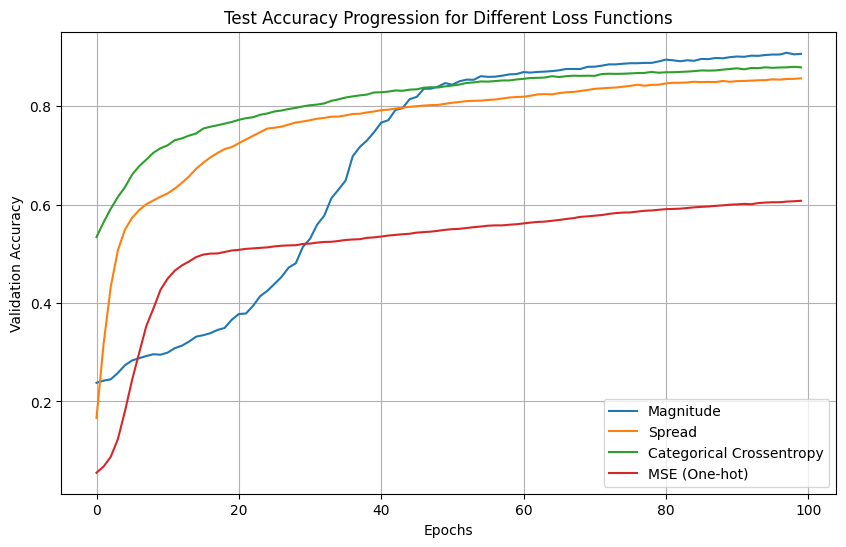

In [111]:
plt.figure(figsize=(10, 6))
for name, acc in results.items():
    plt.plot(acc, label=name)
plt.title("Test Accuracy Progression for Different Loss Functions")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig('mag_loss_plot_iris')
plt.show()

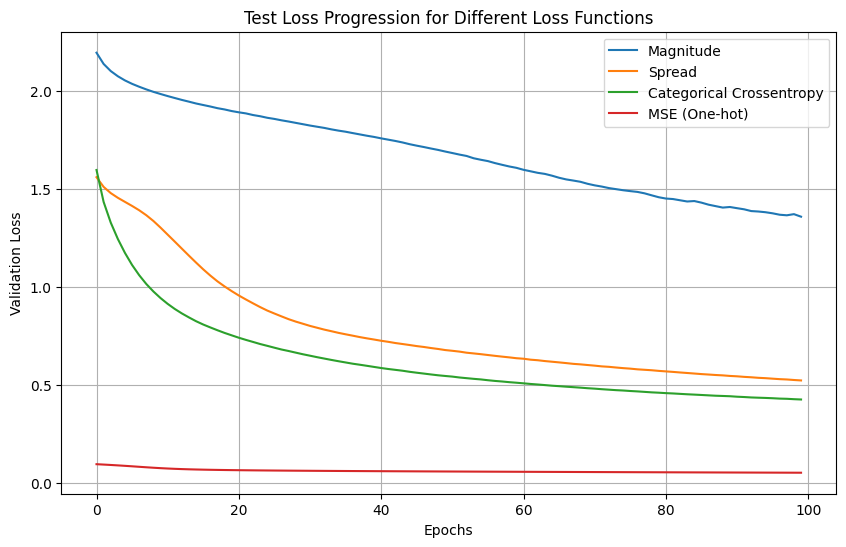

In [112]:
plt.figure(figsize=(10, 6))
for name, acc in losses.items():
    plt.plot(acc, label=name)
plt.title("Test Loss Progression for Different Loss Functions")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig('mag_loss_plot_iris')
plt.show()

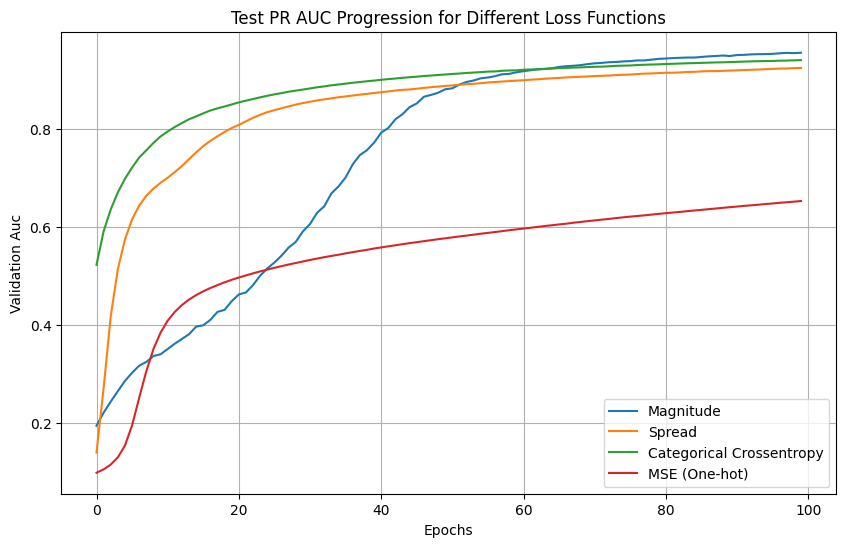

In [113]:
plt.figure(figsize=(10, 6))
for name, acc in aucs.items():
    plt.plot(acc, label=name)
plt.title("Test PR AUC Progression for Different Loss Functions")
plt.xlabel("Epochs")
plt.ylabel("Validation Auc")
plt.legend()
plt.grid(True)
plt.savefig('mag_loss_plot_iris')
plt.show()

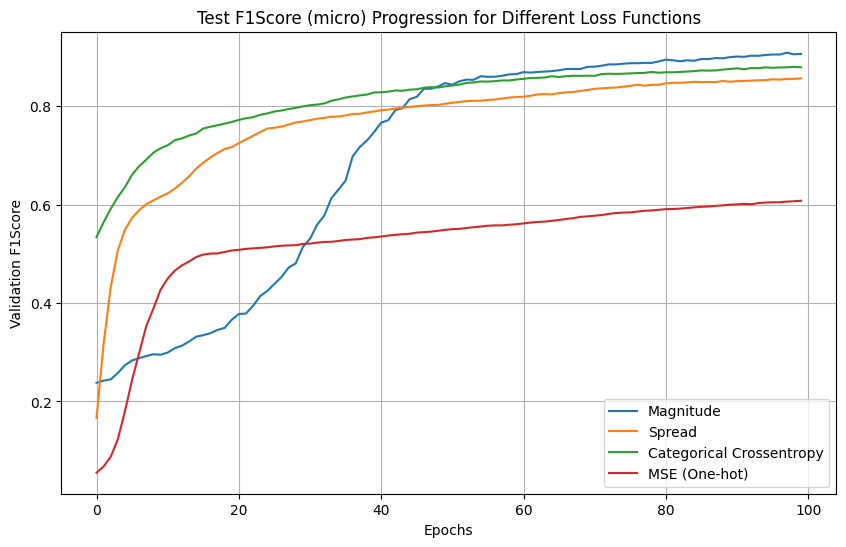

In [114]:
plt.figure(figsize=(10, 6))
for name, acc in micros.items():
    plt.plot(acc, label=name)
plt.title("Test F1Score (micro) Progression for Different Loss Functions")
plt.xlabel("Epochs")
plt.ylabel("Validation F1Score")
plt.legend()
plt.grid(True)
plt.savefig('mag_loss_plot_iris')
plt.show()

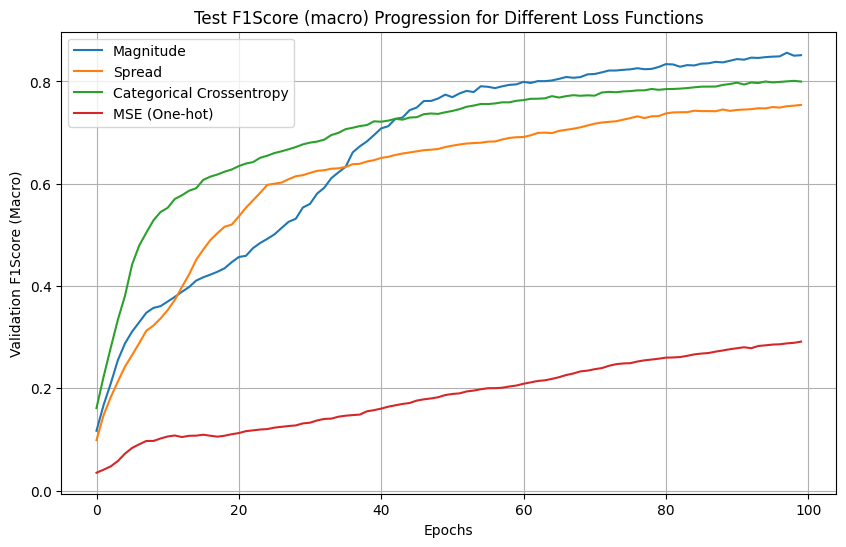

In [115]:
lt.figure(figsize=(10, 6))
for name, acc in macros.items():
    plt.plot(acc, label=name)
plt.title("Test F1Score (macro) Progression for Different Loss Functions")
plt.xlabel("Epochs")
plt.ylabel("Validation F1Score (Macro)")
plt.legend()
plt.grid(True)
plt.savefig('mag_loss_plot_iris')
plt.show()

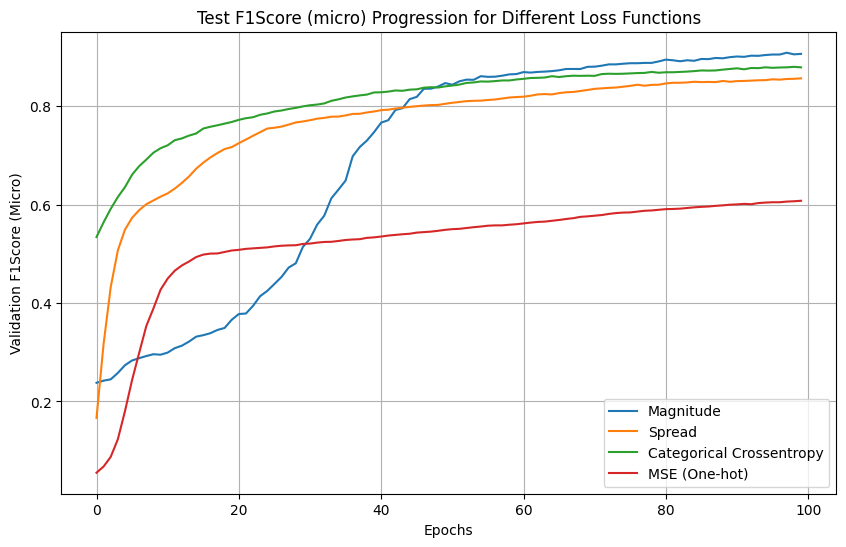

In [117]:
plt.figure(figsize=(10, 6))
for name, acc in micros.items():
    plt.plot(acc, label=name)
plt.title("Test F1Score (micro) Progression for Different Loss Functions")
plt.xlabel("Epochs")
plt.ylabel("Validation F1Score (Micro)")
plt.legend()
plt.grid(True)
plt.savefig('mag_loss_plot_iris')
plt.show()